## Explore SMAC history to find configurations leading to crashes

In [5]:
import os
import math
from pathlib import Path
from smac.runhistory import RunHistory
from smac.scenario import Scenario
import csv

def explore_smac3_runhistory(dir_path):
    """
    Explore SMAC3 runhistory to find hyperparameter combinations that led to crashes.

    Args:
        dir_path (str): Path to the directory containing the JSON logging files.
    """
    scenario = Scenario.load(dir_path)

    runhistory = RunHistory()
    runhistory.load(dir_path / "runhistory.json", scenario.configspace)


    return scenario, runhistory

In [ ]:
# Open a CSV file for writing
with open("problematic_configurations_CGP.csv", "w", newline="") as csvfile:
    fieldnames = ["directory", "lmbda", "mu", "mutation_rate", "num_function_nodes", "strict_selection"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    for base_path in Path().resolve().glob("smac3-output_*CGP*"):
        if base_path.is_dir():
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            base_path = subdirs[0]
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            file_path = subdirs[0]
            #print(file_path)
            scenario, runhistory = explore_smac3_runhistory(file_path)
            for conf in runhistory.config_ids.keys():
                if math.isinf(runhistory.average_cost(conf)):
                    writer.writerow(
                        {
                            "directory": file_path,
                            "lmbda": conf["lmbda"],
                            "mu": conf["mu"],
                            "mutation_rate": conf["mutation_rate"],
                            "num_function_nodes": conf["num_function_nodes"],
                            "strict_selection": conf["strict_selection"],
                        }
                    )

/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_678_visualizing_environmental_CGP_7/d241b5334dc44080d7a6e1ad9a609b39/7
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_557_analcatdata_apnea1_CGP_9/486c2c244af64d4cc415c618129bc797/9
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_CGP_5/b2569288ff59713e6dfdf2c0ac11a795/5
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1028_SWD_CGP_0/785bced121ed9357d2b310f19b705906/0
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_CGP_9/47f3af2c5650e191c2f10717c0a64bde/9
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1193_BNG_lowbwt_CGP_9/fa87d2a6d1545274fb2bef8adf2c0a38/9
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_650_fri_c0_500_50_CGP_8/fb75956e1c02768f5b00ad95d57cbb53/8
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_192_vineyard_CGP_0/5d1f0da4692ed45f7aab3d564f4d

In [ ]:
# Open a CSV file for writing
with open("problematic_configurations_TGP.csv", "w", newline="") as csvfile:
    fieldnames = [
        "directory","cx_rate",
        "discard_infeasible",
        "discard_invalid",
        "mutation_rate",
        "penalization_complexity_factor",
        "penalization_feasibility_factor",
        "penalization_validity_factor",
        "pop_size",
        "tournament_size",
    ]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    for base_path in Path().resolve().glob("smac3-output_*TGP*"):
        if base_path.is_dir():
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            base_path = subdirs[0]
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            file_path = subdirs[0]
            #print(file_path)
            scenario, runhistory = explore_smac3_runhistory(file_path)
            for conf in runhistory.config_ids.keys():
                if math.isinf(runhistory.average_cost(conf)):
                    writer.writerow(
                        {
                            "directory": file_path,
                            "cx_rate": conf["cx_rate"],
                            "discard_infeasible": conf["discard_infeasible"],
                            "discard_invalid": conf["discard_invalid"],
                            "mutation_rate": conf["mutation_rate"],
                            "penalization_complexity_factor": conf["penalization_complexity_factor"],
                            "penalization_feasibility_factor": conf["penalization_feasibility_factor"],
                            "penalization_validity_factor": conf["penalization_validity_factor"],
                            "pop_size": conf["pop_size"],
                            "tournament_size": conf["tournament_size"],
                        }
                    )


/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_TGP_8/3876c60d845cc7713aa23cb8fb97bc28/8
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_678_visualizing_environmental_TGP_6/615cd3e6b95fa4ed66f0f1d3b749262b/6
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_TGP_9/8a7a06b6bf36d874b0db8d9f1a836e94/9
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_606_fri_c2_1000_10_TGP_9/76e958f03d4343268563fcccfd9b2db9/9
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_606_fri_c2_1000_10_TGP_6/1980f47874644044c2bfda0e404a204b/6
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1089_USCrime_TGP_7/3795950982543657b44e7d609db30ba3/7
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_TGP_1/a54bcfd5964003b93d90f4f07b900781/1
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1089_USCrime_TGP_0/d3afc189a2ca63be1f6a4fbd677ee610/0

In [ ]:
# Open a CSV file for writing
with open("problematic_configurations_GE.csv", "w", newline="") as csvfile:
    fieldnames = ["directory", 'cx_rate',
  'discard_infeasible',
  'discard_invalid',
  'mutation_rate',
  'penalization_complexity_factor',
  'penalization_feasibility_factor',
  'penalization_validity_factor',
  'pop_size',
  'tournament_size']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    for base_path in Path().resolve().glob("smac3-output_*GE*"):
        if base_path.is_dir():
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            base_path = subdirs[0]
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            file_path = subdirs[0]
            #print(file_path)
            scenario, runhistory = explore_smac3_runhistory(file_path)
            for conf in runhistory.config_ids.keys():
                if math.isinf(runhistory.average_cost(conf)):
                    writer.writerow(
                        {
                            "directory": file_path,
                            "cx_rate": conf["cx_rate"],
                            "discard_infeasible": conf["discard_infeasible"],
                            "discard_invalid": conf["discard_invalid"],
                            "penalization_complexity_factor": conf["penalization_complexity_factor"],
                            "penalization_feasibility_factor": conf["penalization_feasibility_factor"],
                            "penalization_validity_factor": conf["penalization_validity_factor"],
                            "pop_size": conf["pop_size"],
                            "tournament_size": conf["tournament_size"],
                        }
                    )


/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_557_analcatdata_apnea1_GE_4/c3db7f58199c099d06490643e55d614e/4
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1089_USCrime_GE_6/4190ced3adbdae156bc2482c58e4e08f/6
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1089_USCrime_GE_1/ee9f30af85415360ab70b7fc10a1f7a6/1
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_606_fri_c2_1000_10_GE_4/1f7ce3b707190aaf25804b13b41aa557/4
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_GE_5/233816ee9f7fd1df27e4b0c7006d1b48/5
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1199_BNG_echoMonths_GE_2/3bb20bfc14e88b1ed4353e903dff06cd/2
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_678_visualizing_environmental_GE_6/facb81361ccf0c0a49706ab7abae0717/6
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1199_BNG_echoMonths_GE_0/4d5cf539a8c6a352

In [ ]:
# Open a CSV file for writing
with open("problematic_configurations_LGP.csv", "w", newline="") as csvfile:
    fieldnames = [
        "directory",
        "branch_probability",
        "initial_max_len",
        "insertion_rate",
        "macro_variation_rate",
        "max_len",
        "max_segment",
        "micro_variation_rate",
        "p_register",
        "reproduction_rate",
    ]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

    # Write the header
    writer.writeheader()

    for base_path in Path().resolve().glob("smac3-output_*LGP*"):
        if base_path.is_dir():
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            base_path = subdirs[0]
            subdirs = [d for d in base_path.iterdir() if d.is_dir()]
            if not subdirs:
                continue
            file_path = subdirs[0]
            #print(file_path)
            scenario, runhistory = explore_smac3_runhistory(file_path)
            for conf in runhistory.config_ids.keys():
                if math.isinf(runhistory.average_cost(conf)):
                    writer.writerow(
                        {
                            "directory": file_path,
                            "branch_probability": conf["branch_probability"],
                            "initial_max_len": conf["initial_max_len"],
                            "insertion_rate": conf["insertion_rate"],
                            "macro_variation_rate": conf["macro_variation_rate"],
                            "max_len": conf["max_len"],
                            "max_segment": conf["max_segment"],
                            "micro_variation_rate": conf["micro_variation_rate"],
                            "p_register": conf["p_register"],
                            "reproduction_rate": conf["reproduction_rate"],
                        }
                    )


,

/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_192_vineyard_LGP_6/a97d35eee05876c34ee6e068d6e43187/6
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1089_USCrime_LGP_0/b70c43dfa0722022cbee619fe9235f73/0
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_210_cloud_LGP_1/e91b4249f0d0d94a0251a208886e4615/1
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_522_pm10_LGP_2/4037d6b90804530968305c4b64337df7/2
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_606_fri_c2_1000_10_LGP_0/33b1d941ba20ee3569535a153a967772/0
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1193_BNG_lowbwt_LGP_8/3edfab788506e9988514e74a103aa821/8
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_1028_SWD_LGP_2/a5a30d1123be06ac2e43a82cfb1830f0/2
/storage/work/anastacio/TinyverseGP/experiments_scripts/smac3-output_579_fri_c0_250_5_LGP_2/3fbc46b41c03bf7a3485d9281e2801ab/2
/storage/work/

''

## For each problem, plot default against optimised

In [18]:
import pandas as pd

datasets = [
    "522_pm10",
    "678_visualizing_environmental",
    "192_vineyard",
    "1028_SWD",
    "1199_BNG_echoMonths",
    "210_cloud",
    "1089_USCrime",
    "1193_BNG_lowbwt",
    "557_analcatdata_apnea1",
    "650_fri_c0_500_50",
    "579_fri_c0_250_5",
    "606_fri_c2_1000_10",
]

dfs = []

for dataset in datasets:
    for algo in ["CGP", "TGP", "GE", "LGP"]:
        for seed in range(10):
            csv_file = f"output_data/{dataset}_{algo}_{seed}.csv"
            # Load each non-empty file into a DataFrame and append to the list
            if os.path.getsize(csv_file) > 0:  # Check if the file is not empty
                df = pd.read_csv(csv_file)
                dfs.append(df)

# Concatenate all DataFrames into one
if dfs:  # Check if the list is not empty
    combined_df = pd.concat(dfs, ignore_index=True)
    print("Combined DataFrame shape:", combined_df.shape)
    print("Combined DataFrame with finished optimisation:", combined_df[combined_df["nb_trials"] == 200].shape)
else:
    print("No valid CSV files found or all files are empty.")
    


Combined DataFrame shape: (365, 10)
Combined DataFrame with finished optimisation: (122, 10)


/tmp/ipykernel_3862898/1400267795.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["def_test_normalized"] = df.apply(
/tmp/ipykernel_3862898/1400267795.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["opt_test_normalized"] = df.apply(


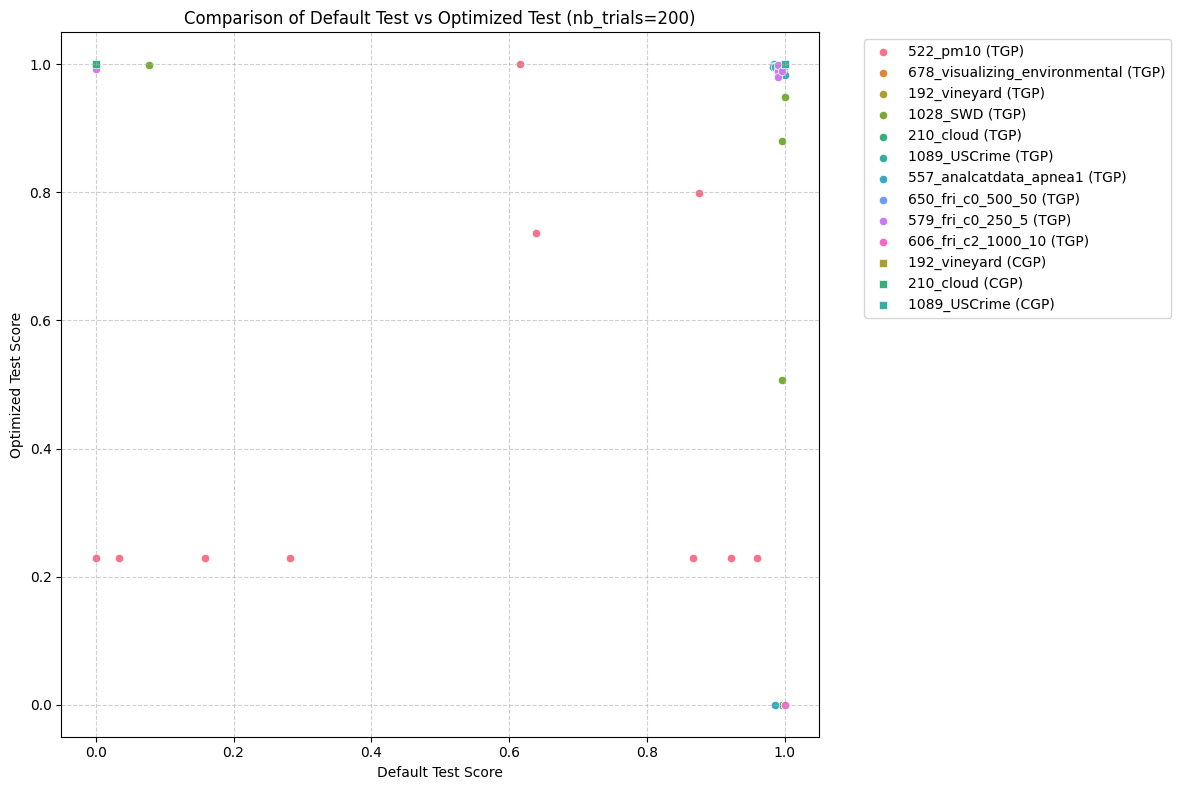

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your DataFrame is named `combined_df`
filtered_df = combined_df[combined_df["nb_trials"] == 200]

# Normalize 'def_test' and 'opt_test' dataset-wise
def normalize_datasetwise(df):
    datasets = filtered_df['dataset_name'].unique()
    min_max = {}
    for dataset in datasets:
        dataset_df = df[df['dataset_name'] == dataset]
        min_max[dataset] = (min(dataset_df['def_test'].min(),dataset_df['opt_test'].min()),
                            max(dataset_df['def_test'].max(),dataset_df['opt_test'].max()))
    df["def_test_normalized"] = df.apply(
        lambda row: (row["def_test"] - min_max[row["dataset_name"]][0])
        / (min_max[row["dataset_name"]][1] - min_max[row["dataset_name"]][0]),
        axis=1,
    )
    df["opt_test_normalized"] = df.apply(
        lambda row: (row["opt_test"] - min_max[row["dataset_name"]][0])
        / (min_max[row["dataset_name"]][1] - min_max[row["dataset_name"]][0]),
        axis=1,
    )
    return df

# Map dataset names to colors (using a colormap)
unique_datasets = filtered_df["dataset_name"].unique()
color_palette = sns.color_palette("husl", n_colors=len(unique_datasets))
dataset_to_color = {dataset: color for dataset, color in zip(unique_datasets, color_palette)}

# Map algorithms to symbols
unique_algos = filtered_df["algo_name"].unique()
algo_to_symbol = {algo: marker for algo, marker in zip(unique_algos, ["o", "s", "D", "^"])}  # Circle, square, diamond, triangle

normalised_df = normalize_datasetwise(filtered_df)
# Create the plot
plt.figure(figsize=(12, 8))
for algo in unique_algos:
    for dataset in unique_datasets:
        subset = normalised_df[(normalised_df["algo_name"] == algo) & (normalised_df["dataset_name"] == dataset)]
        if not subset.empty:
            sns.scatterplot(
                data=subset,
                x="def_test_normalized",
                y="opt_test_normalized",
                color=dataset_to_color[dataset],
                marker=algo_to_symbol[algo],
                label=f"{dataset} ({algo})",
            )

# Customize the plot
plt.title("Comparison of Default Test vs Optimized Test (nb_trials=200)")
plt.xlabel("Default Test Score")
plt.ylabel("Optimized Test Score")
plt.grid(True, linestyle="--", alpha=0.6)

# Add legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # Remove duplicate labels
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
